In [1]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

current_dir = os.getcwd()

gcad_dir = os.path.join(current_dir, 'GCAD')
if gcad_dir not in sys.path:
    sys.path.append(gcad_dir)
import define_circuit

from active_learning_loop._designer import ExperimentDesigner

# 1. Load the selected M circuits
with open(os.path.join(current_dir, 'selected_M_circuits.pkl'), 'rb') as f:
    circuits_list = pickle.load(f)

# Convert list to our required dictionary format
circuit_dict = {f"Circuit_{i+1}": c for i, c in enumerate(circuits_list)}
print(f"✅ Loaded {len(circuit_dict)} circuits into Dictionary.")

# 2. Load the Prior Belief Ensemble
cloud_path = os.path.join(current_dir, 'active_learning_loop', 'al_memory', 'prior_belief_cloud_N200_spread2.0.pkl')
with open(cloud_path, 'rb') as f:
    belief_cloud = pickle.load(f)
print(f"✅ Loaded Belief Ensemble with {len(belief_cloud)} models.")

# 3. Load the nominal promoter params (we keep these fixed)
with open(os.path.join(current_dir, 'GCAD', 'promo.pkl'), 'rb') as f:
    promo_params = pickle.load(f)

✅ Loaded 3 circuits into Dictionary.
✅ Loaded Belief Ensemble with 200 models.


### A. Time-Specific Variance

In [2]:
np.random.seed(42)

DOSAGES = np.arange(0.2, 4.2, 0.2)
P_CIRCUITS = 2   
Q_DOSAGES = 2    
VAR_METRIC = "time_specific"

designer = ExperimentDesigner(
    circuit_dict=circuit_dict, 
    candidate_dosages=DOSAGES, 
    variance_metric=VAR_METRIC, 
    p_circuits=P_CIRCUITS, 
    q_dosages=Q_DOSAGES
)

print(f"--- RUNNING DESIGNER ({VAR_METRIC}) ---")
print(f"Simulating {len(belief_cloud)} models x {len(circuit_dict)} circuits x {len(DOSAGES)} dosages = {len(belief_cloud)*len(circuit_dict)*len(DOSAGES)} ODE solves...")

selected_experiments, variance_matrix, selected_indices, max_u, all_simulations = designer.design_experiment(belief_cloud, promo_params)

print("\n🎯 SELECTED EXPERIMENTS:")
for exp in selected_experiments:
    print(f"   -> {exp[0]} at {exp[1]:.2f}x dosage")

--- RUNNING DESIGNER (time_specific) ---
Simulating 200 models x 3 circuits x 20 dosages = 12000 ODE solves...


Simulating 2D Grid: 100%|██████████| 60/60 [14:13<00:00, 14.23s/exp]


🎯 SELECTED EXPERIMENTS:
   -> Circuit_3 at 2.20x dosage
   -> Circuit_3 at 2.40x dosage
   -> Circuit_1 at 1.80x dosage
   -> Circuit_1 at 1.60x dosage


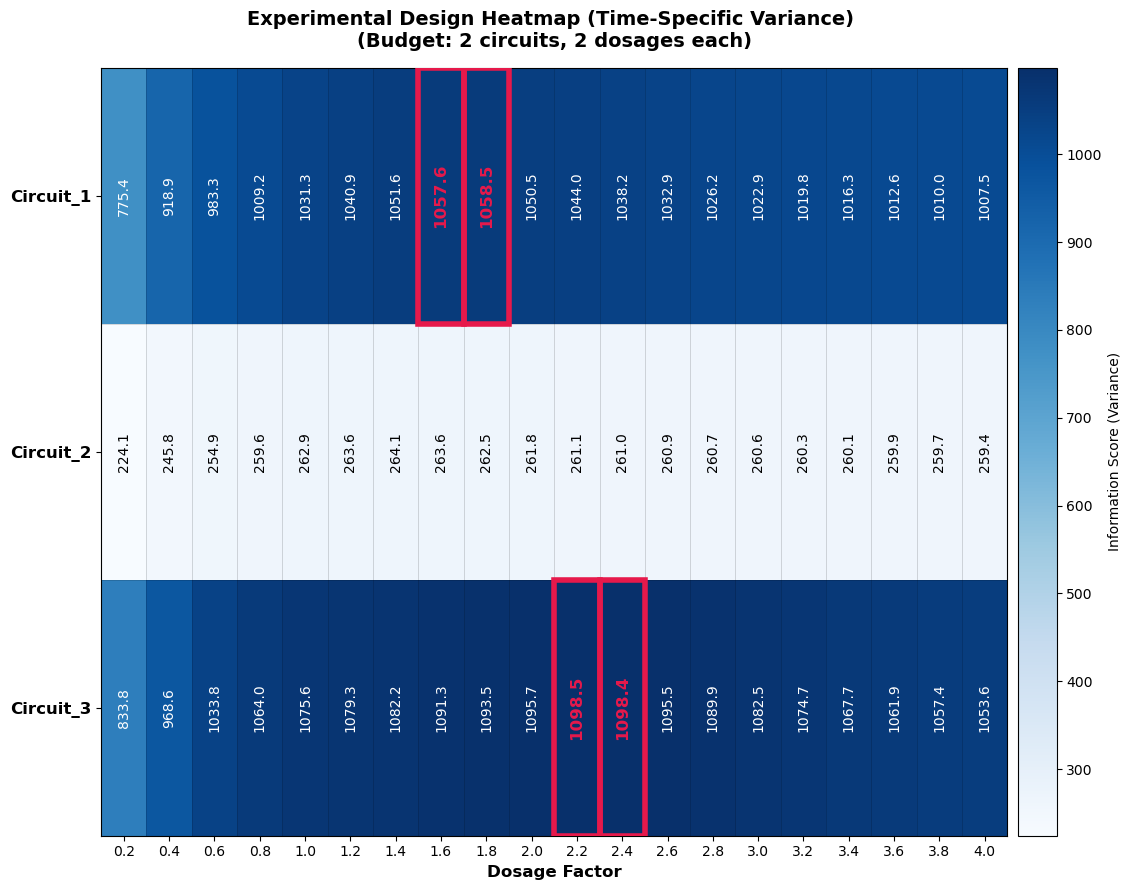

In [3]:
fig, ax = plt.subplots(figsize=(12, 9))

cmap = 'Blues'
cax = ax.imshow(variance_matrix, aspect='auto', cmap=cmap)
fig.colorbar(cax, label='Information Score (Variance)', pad=0.01)

ax.set_yticks(np.arange(len(circuit_dict)))
ax.set_yticklabels(list(circuit_dict.keys()), fontweight='bold', fontsize=12)
ax.set_xticks(np.arange(len(DOSAGES)))
ax.set_xticklabels([f"{d:.1f}" for d in DOSAGES], rotation=0, fontsize=10)
ax.set_xlabel('Dosage Factor', fontweight='bold', fontsize=12)
ax.set_title(f'Experimental Design Heatmap (Time-Specific Variance) \n(Budget: {P_CIRCUITS} circuits, {Q_DOSAGES} dosages each)', 
             fontweight='bold', fontsize=14, pad=15)

max_var = np.max(variance_matrix) if np.max(variance_matrix) > 0 else 1.0

for i in range(variance_matrix.shape[0]):
    for j in range(variance_matrix.shape[1]):
        val = variance_matrix[i, j]
        is_selected = (i, j) in selected_indices
        
        if is_selected:
            rect = Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='#e6194B', lw=4, zorder=3)
            ax.add_patch(rect)
            # ROTATED TEXT FOR SELECTED
            ax.text(j, i, f"{val:.1f}", color='#e6194B', ha='center', va='center', 
                    fontweight='heavy', fontsize=12, rotation=90, zorder=4)
        else:
            text_color = 'white' if (val / max_var) > 0.6 else 'black'
            # ROTATED TEXT FOR UNSELECTED
            ax.text(j, i, f"{val:.1f}", color=text_color, ha='center', va='center', 
                    fontsize=10, rotation=90, zorder=4)

ax.set_xticks(np.arange(-0.5, len(DOSAGES), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(circuit_dict), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5, alpha=0.2)
ax.tick_params(which="minor", size=0)

plt.tight_layout()
plt.show()

In [4]:
al_memory_dir = os.path.join(current_dir, 'active_learning_loop', 'al_memory')

# Create dynamic filenames based on the chosen metric
decision_filename = f'designer_decisions_{VAR_METRIC}_cycle_0.pkl'
cache_filename = f'designer_simulations_{VAR_METRIC}_cache_cycle_0.pkl'

decision_path = os.path.join(al_memory_dir, decision_filename)
cache_path = os.path.join(al_memory_dir, cache_filename)

# 1. Save the decision data
output_data = {
    'selected_experiments': selected_experiments,
    'variance_matrix': variance_matrix,
    'candidate_dosages': DOSAGES,
    'selected_indices': selected_indices
}
with open(decision_path, 'wb') as f:
    pickle.dump(output_data, f)
    
# 2. Save the heavy simulation cache
with open(cache_path, 'wb') as f:
    pickle.dump(all_simulations, f)

print(f"✅ Saved designer decisions to '{decision_filename}'")
print(f"✅ Saved simulation data to '{cache_filename}'")

✅ Saved designer decisions to 'designer_decisions_time_specific_cycle_0.pkl'
✅ Saved simulation data to 'designer_simulations_time_specific_cache_cycle_0.pkl'


### B. Hybrid Variance

(Note: `Score = (0.7 * Normalized_Prominence_Var) + (0.3 * Normalized_Time_Var)`)

In [ ]:
np.random.seed(42)

DOSAGES = np.arange(0.2, 4.2, 0.2)
P_CIRCUITS = 2   
Q_DOSAGES = 2    
VAR_METRIC = "hybrid"

designer = ExperimentDesigner(
    circuit_dict=circuit_dict, 
    candidate_dosages=DOSAGES, 
    variance_metric=VAR_METRIC, 
    p_circuits=P_CIRCUITS, 
    q_dosages=Q_DOSAGES
)

print(f"--- RUNNING DESIGNER ({VAR_METRIC}) ---")
print(f"Simulating {len(belief_cloud)} models x {len(circuit_dict)} circuits x {len(DOSAGES)} dosages = {len(belief_cloud)*len(circuit_dict)*len(DOSAGES)} ODE solves...")

selected_experiments, variance_matrix, selected_indices, max_u, all_simulations = designer.design_experiment(belief_cloud, promo_params)

print("\n🎯 SELECTED EXPERIMENTS:")
for exp in selected_experiments:
    print(f"   -> {exp[0]} at {exp[1]:.2f}x dosage")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

cmap = 'Blues'
cax = ax.imshow(variance_matrix, aspect='auto', cmap=cmap)
fig.colorbar(cax, label='Information Score (Variance)', pad=0.01)

ax.set_yticks(np.arange(len(circuit_dict)))
ax.set_yticklabels(list(circuit_dict.keys()), fontweight='bold', fontsize=12)
ax.set_xticks(np.arange(len(DOSAGES)))
ax.set_xticklabels([f"{d:.1f}" for d in DOSAGES], rotation=0, fontsize=10)
ax.set_xlabel('Dosage Factor', fontweight='bold', fontsize=12)
ax.set_title(f'Experimental Design Heatmap (Hybrid Variance)\n(Budget: {P_CIRCUITS} circuits, {Q_DOSAGES} dosages each)', 
             fontweight='bold', fontsize=14, pad=15)

max_var = np.max(variance_matrix) if np.max(variance_matrix) > 0 else 1.0

for i in range(variance_matrix.shape[0]):
    for j in range(variance_matrix.shape[1]):
        val = variance_matrix[i, j]
        is_selected = (i, j) in selected_indices
        
        if is_selected:
            rect = Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='#e6194B', lw=4, zorder=3)
            ax.add_patch(rect)
            # ROTATED TEXT FOR SELECTED
            ax.text(j, i, f"{val:.1f}", color='#e6194B', ha='center', va='center', 
                    fontweight='heavy', fontsize=12, rotation=90, zorder=4)
        else:
            text_color = 'white' if (val / max_var) > 0.6 else 'black'
            # ROTATED TEXT FOR UNSELECTED
            ax.text(j, i, f"{val:.1f}", color=text_color, ha='center', va='center', 
                    fontsize=10, rotation=90, zorder=4)

ax.set_xticks(np.arange(-0.5, len(DOSAGES), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(circuit_dict), 1), minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5, alpha=0.2)
ax.tick_params(which="minor", size=0)

plt.tight_layout()
plt.show()

In [ ]:
al_memory_dir = os.path.join(current_dir, 'active_learning_loop', 'al_memory')

# Create dynamic filenames based on the chosen metric
decision_filename = f'designer_decisions_{VAR_METRIC}_cycle_0.pkl'
cache_filename = f'designer_simulations_{VAR_METRIC}_cache_cycle_0.pkl'

decision_path = os.path.join(al_memory_dir, decision_filename)
cache_path = os.path.join(al_memory_dir, cache_filename)

# 1. Save the decision data
output_data = {
    'selected_experiments': selected_experiments,
    'variance_matrix': variance_matrix,
    'candidate_dosages': DOSAGES,
    'selected_indices': selected_indices
}
with open(decision_path, 'wb') as f:
    pickle.dump(output_data, f)
    
# 2. Save the heavy simulation cache
with open(cache_path, 'wb') as f:
    pickle.dump(all_simulations, f)

print(f"✅ Saved designer decisions to '{decision_filename}'")
print(f"✅ Saved simulation data to '{cache_filename}'")